# 🧪 Notebook 3: Statistical Significance Testing

**Purpose:** Run the appropriate significance test for each scenario using the auto-selection
decision tree. This notebook tests all three scenarios and documents *why* each test was chosen.

### Test Selection Decision Tree

```
Is the metric a proportion (CVR, CTR, phone rate)?
  └─ YES → Two-Proportion Z-Test

Is sample size < 30 per group?
  └─ YES → Bootstrap

Is data normally distributed? (Shapiro-Wilk / KS test)
  └─ NO → Mann-Whitney U (non-parametric)
  └─ YES → Are variances equal? (Levene's test)
           └─ YES → Student's t-test
           └─ NO  → Welch's t-test
```


In [1]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from ab_tests import (select_and_run_test, run_proportions_ztest,
                      run_mann_whitney, run_bootstrap, assess_practical_significance)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4, 'font.family': 'sans-serif',
    'axes.spines.top': False, 'axes.spines.right': False,
})

s1 = pd.read_csv('../data/scenario1_ship_it.csv')
s2 = pd.read_csv('../data/scenario2_do_not_ship.csv')
s3 = pd.read_csv('../data/scenario3_inconclusive.csv')
print("Datasets loaded")

Datasets loaded


---
## Scenario 1: CTA Button Test — Conversion Rate (Proportion Metric)

**Metric:** Binary conversion (0/1). Use Two-Proportion Z-Test.

In [2]:
s1_ctrl = s1[s1['group'] == 'control']
s1_var  = s1[s1['group'] == 'variant']

result1 = select_and_run_test(
    control=None, variant=None,
    metric_type='proportion',
    control_conversions=s1_ctrl['converted'].sum(),
    control_visitors=len(s1_ctrl),
    variant_conversions=s1_var['converted'].sum(),
    variant_visitors=len(s1_var),
    alpha=0.05
)

practical1 = assess_practical_significance(result1['relative_lift_pct'], min_business_lift_pct=10.0)

print("SCENARIO 1 — Z-TEST RESULTS")
print("=" * 60)
print(f"  Test selected:       {result1['test']}")
print(f"  Decision log:        {result1['decision_log']}")
print(f"  Control CVR:         {result1['control_rate']:.2%}")
print(f"  Variant CVR:         {result1['variant_rate']:.2%}")
print(f"  Absolute lift:       {result1['absolute_lift']:+.4f} ({result1['relative_lift_pct']:+.1f}% relative)")
print(f"  Z-statistic:         {result1['z_statistic']}")
print(f"  P-value:             {result1['p_value']}")
print(f"  Significant:         {result1['is_significant']}")
print(f"  Practical sig:       {practical1['is_practically_significant']}")
print(f"\n  {result1['interpretation']}")
print(f"  {practical1['interpretation']}")

SCENARIO 1 — Z-TEST RESULTS
  Test selected:       Two-Proportion Z-Test
  Decision log:        ['Metric type: proportion → running Two-Proportion Z-Test.']
  Control CVR:         8.03%
  Variant CVR:         9.47%
  Absolute lift:       +0.0143 (+17.8% relative)
  Z-statistic:         2.7784
  P-value:             0.005464
  Significant:         True
  Practical sig:       True

  ✅ Statistically significant. Variant CVR (9.47%) vs Control (8.03%). Relative lift: 17.8% (p=0.0055).
  ✅ Lift of 17.8% exceeds business threshold of 10.0%.


---
## Scenario 2: Homepage Headline Test — Revenue per User (Continuous, Skewed)

**Metric:** Revenue (right-skewed). Auto-selector will detect non-normality and use Mann-Whitney U.

In [3]:
s2_ctrl_rev = s2[s2['group'] == 'control']['revenue_usd'].values
s2_var_rev  = s2[s2['group'] == 'variant']['revenue_usd'].values

result2 = select_and_run_test(s2_ctrl_rev, s2_var_rev, metric_type='continuous', alpha=0.05)
practical2 = assess_practical_significance(result2.get('relative_lift_pct', result2.get('median_lift_pct', 0)), 5.0)

print("SCENARIO 2 — AUTO-SELECTED TEST RESULTS")
print("=" * 60)
print(f"  Test selected:       {result2['test']}")
print(f"  Decision log:        {result2['decision_log']}")
print(f"  Control median rev:  ${result2.get('control_median', 0):.2f}")
print(f"  Variant median rev:  ${result2.get('variant_median', 0):.2f}")
print(f"  Lift:                {result2.get('median_lift_pct', result2.get('relative_lift_pct', 0)):+.1f}%")
print(f"  P-value:             {result2['p_value']}")
print(f"  Significant:         {result2['is_significant']}")
print(f"\n  {result2['interpretation']}")
print(f"  {practical2['interpretation']}")

SCENARIO 2 — AUTO-SELECTED TEST RESULTS
  Test selected:       Mann-Whitney U Test
  Decision log:        ['Non-normal distribution detected → running Mann-Whitney U.']
  Control median rev:  $45.25
  Variant median rev:  $44.98
  Lift:                -0.6%
  P-value:             0.757659
  Significant:         False

  ❌ Not statistically significant (p=0.7577).
  ⚠️ Lift of -0.6% is below business threshold of 5.0%. Statistically significant but may not be worth shipping.


---
## Scenario 3: Form Redesign — CVR with Novelty Effect

**Metric:** Conversion rate. We note the novelty effect from Notebook 2. We run the test but flag the caveat.

In [4]:
s3_ctrl = s3[s3['group'] == 'control']
s3_var  = s3[s3['group'] == 'variant']

result3 = select_and_run_test(
    control=None, variant=None,
    metric_type='proportion',
    control_conversions=s3_ctrl['converted'].sum(),
    control_visitors=len(s3_ctrl),
    variant_conversions=s3_var['converted'].sum(),
    variant_visitors=len(s3_var),
    alpha=0.05
)
practical3 = assess_practical_significance(result3['relative_lift_pct'], 5.0)

print("SCENARIO 3 — Z-TEST RESULTS (novelty effect noted)")
print("=" * 60)
print(f"  Control CVR:         {result3['control_rate']:.2%}")
print(f"  Variant CVR:         {result3['variant_rate']:.2%}")
print(f"  Relative lift:       {result3['relative_lift_pct']:+.1f}%")
print(f"  P-value:             {result3['p_value']}")
print(f"  Significant:         {result3['is_significant']}")
print(f"\n  {result3['interpretation']}")
print(f"  NOTE: Novelty effect detected in Notebook 2 — results unreliable. Extend experiment.")

SCENARIO 3 — Z-TEST RESULTS (novelty effect noted)
  Control CVR:         6.35%
  Variant CVR:         6.90%
  Relative lift:       +8.7%
  P-value:             0.161942
  Significant:         False

  ❌ Not statistically significant (p=0.1619). Cannot conclude the variant outperforms control.
  NOTE: Novelty effect detected in Notebook 2 — results unreliable. Extend experiment.


---
## Results Visualization — All Three Scenarios

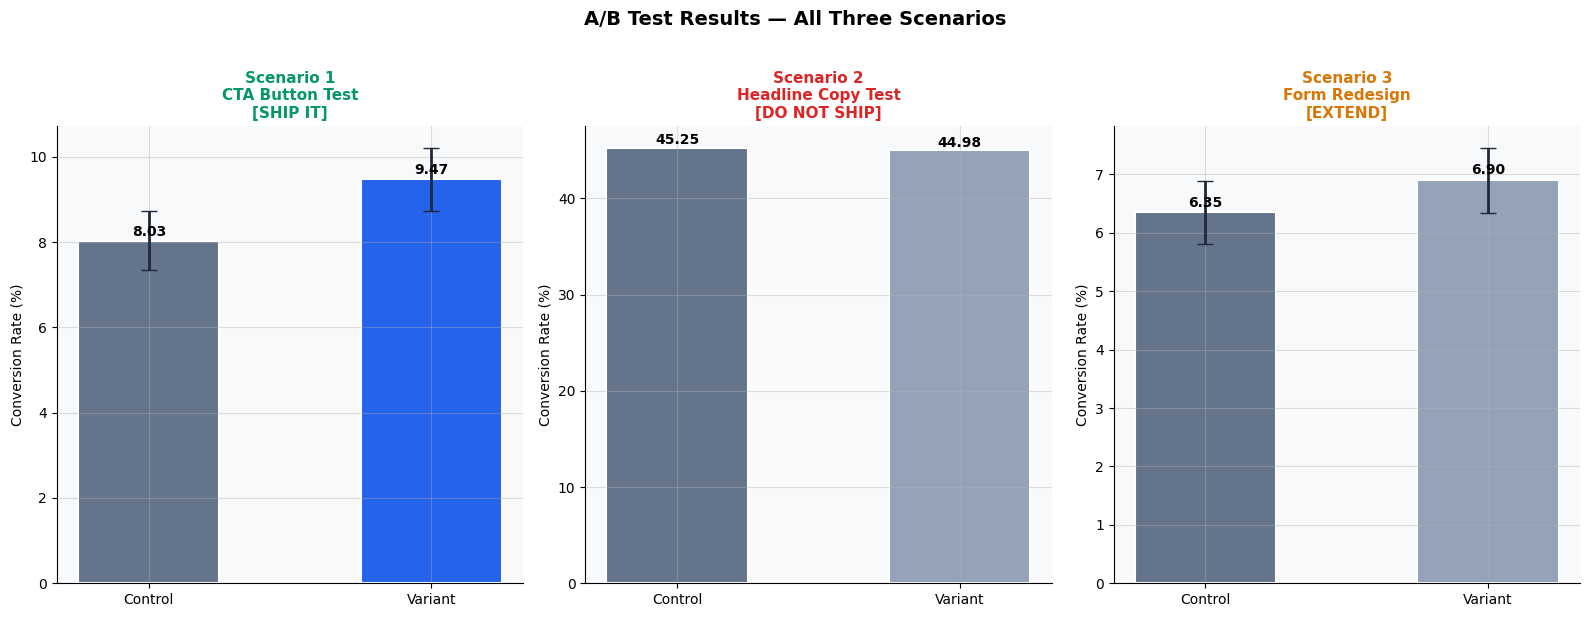

Saved to outputs/03_test_results.png
Results exported to outputs/test_results.json


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

scenarios = [
    ("Scenario 1\nCTA Button Test", result1['control_rate']*100, result1['variant_rate']*100,
     result1['ci_control'], result1['ci_variant'], result1['is_significant'], "SHIP IT"),
    ("Scenario 2\nHeadline Copy Test", result2['control_median'], result2['variant_median'],
     None, None, result2['is_significant'], "DO NOT SHIP"),
    ("Scenario 3\nForm Redesign", result3['control_rate']*100, result3['variant_rate']*100,
     result3['ci_control'], result3['ci_variant'], result3['is_significant'], "EXTEND"),
]

for ax, (title, ctrl_val, var_val, ci_c, ci_v, sig, verdict) in zip(axes, scenarios):
    colors = ['#64748b', '#2563eb' if sig else '#94a3b8']
    bars = ax.bar(['Control', 'Variant'], [ctrl_val, var_val], color=colors,
                  width=0.5, edgecolor='white', linewidth=1.5)

    if ci_c and ci_v:
        ax.errorbar(['Control', 'Variant'],
                    [ctrl_val, var_val],
                    yerr=[[ctrl_val - ci_c[0]*100, var_val - ci_v[0]*100],
                          [ci_c[1]*100 - ctrl_val, ci_v[1]*100 - var_val]],
                    fmt='none', color='#1e293b', capsize=6, linewidth=2)

    verdict_colors = {'SHIP IT': '#059669', 'DO NOT SHIP': '#dc2626', 'EXTEND': '#d97706'}
    ax.set_title(f"{title}\n[{verdict}]", fontsize=11, fontweight='bold',
                 color=verdict_colors.get(verdict, '#1e293b'))
    ax.set_ylabel('Conversion Rate (%)' if 'Test' in title or 'Redesign' in title else 'Median Revenue ($)')
    for bar, val in zip(bars, [ctrl_val, var_val]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('A/B Test Results — All Three Scenarios', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/03_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/03_test_results.png")

# Also save results for notebook 4
import json
import numpy as np

def make_serializable(d):
    out = {}
    for k, v in d.items():
        if isinstance(v, tuple): out[k] = list(v)
        elif isinstance(v, (np.bool_, bool)): out[k] = bool(v)
        elif isinstance(v, (np.integer,)): out[k] = int(v)
        elif isinstance(v, (np.floating,)): out[k] = float(v)
        elif isinstance(v, dict): out[k] = make_serializable(v)
        else: out[k] = v
    return out

results_export = {
    "scenario1": make_serializable({**result1, "practical": make_serializable(practical1.__class__(practical1) if not isinstance(practical1, dict) else practical1), "verdict": "SHIP IT"}),
    "scenario2": make_serializable({**result2, "practical": make_serializable(practical2 if isinstance(practical2, dict) else {}), "verdict": "DO NOT SHIP"}),
    "scenario3": make_serializable({**result3, "practical": make_serializable(practical3 if isinstance(practical3, dict) else {}), "verdict": "EXTEND EXPERIMENT"}),
}
for sc in results_export.values():
    sc.pop('decision_log', None)
with open('../outputs/test_results.json', 'w') as fp:
    json.dump(results_export, fp, indent=2)
print("Results exported to outputs/test_results.json")

**Next step → Notebook 04: Business Recommendations**